In [119]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

read the data 


In [120]:
df = pd.read_csv(r"C:\Users\admin\Downloads\finance engeniering\data science\dataset\ultimate_student_productivity_dataset_5000.csv")
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


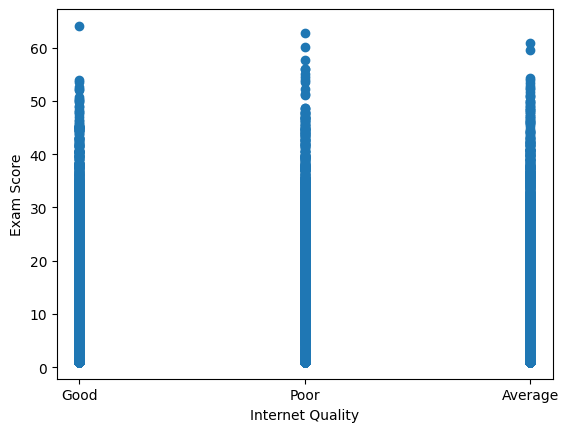

In [121]:
plt.scatter(df['internet_quality'], df['exam_score'])
plt.xlabel("Internet Quality")
plt.ylabel("Exam Score")
plt.show()

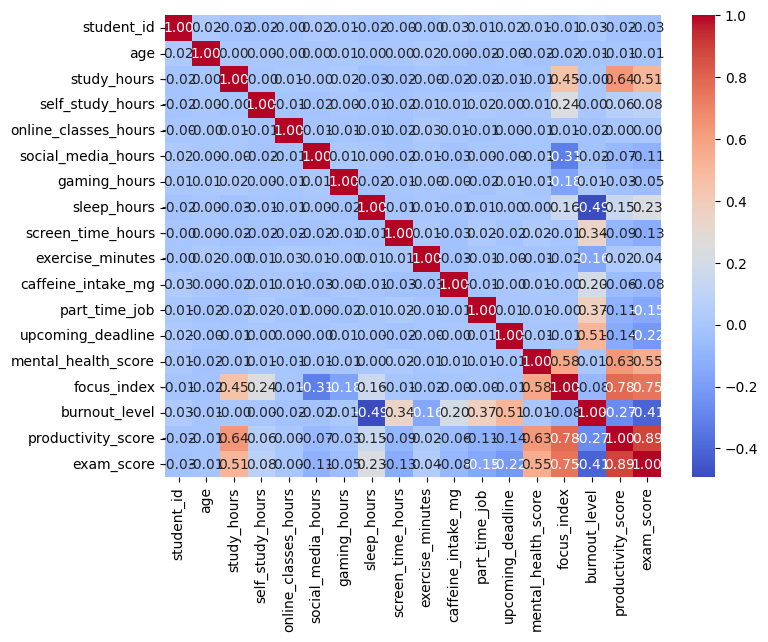

In [122]:
import seaborn as sns
corr_target = df.select_dtypes(include='number').corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_target, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

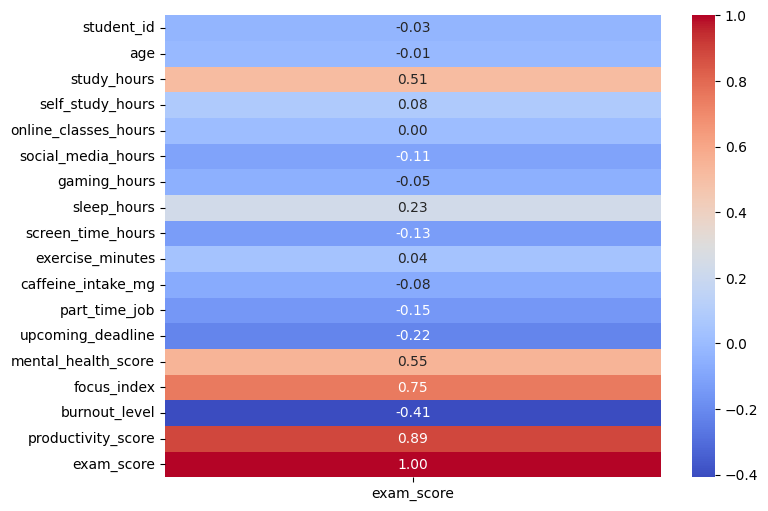

In [123]:
corr_target = df.select_dtypes(include='number').corr()['exam_score']
corr_target = corr_target.to_frame()
plt.figure(figsize=(8,6))
sns.heatmap(corr_target, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [124]:
df.isnull().sum()

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

IN the prediction we will include 
<p>study hours,self study hours , social media hours , screen time hours ,exrecise minute , part time job , sleep hours mental_health_score</p>

In [125]:
X = df[[
    'study_hours',
    'self_study_hours',
    'online_classes_hours',
    'social_media_hours',
    'screen_time_hours',
    'exercise_minutes',
    'part_time_job',
    'sleep_hours',
    'mental_health_score',
    'caffeine_intake_mg'
]]
y = df[[
    'focus_index',
    'burnout_level',
    'productivity_score',
    'exam_score'
]]


In [126]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X = StandardScaler().fit_transform(X)
y = StandardScaler().fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [127]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge 
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
model = GridSearchCV(Ridge(), {"alpha": [0.1, 1, 10, 100]}, cv=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.2933924393395471
R2 Score: 0.690739390570993


In [128]:
from sklearn.ensemble import RandomForestRegressor
model_random = RandomForestRegressor(n_estimators = 100 , random_state = 42)
model_random.fit(X_train, y_train)
y_pred = model_random.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.3443306153878565
R2 Score: 0.6372699580531725


In [129]:
from sklearn.tree import DecisionTreeRegressor
model_tree = DecisionTreeRegressor(
    random_state=42,
    max_depth=10,       # limit tree depth
    min_samples_leaf=5 # minimum samples per leaf
)
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.5116825643012822
R2 Score: 0.46072720637799025


In [130]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
y_preds = []
for i in range(y_train.shape[1]):
    svr = SVR(kernel='linear', C=10, epsilon=0.1)
    svr.fit(X_train, y_train[:, i])  # select one target column
    y_pred_i = svr.predict(X_test)
    y_preds.append(y_pred_i)
y_pred = np.column_stack(y_preds)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.29416640713827125
R2 Score: 0.6899225912501215


In [131]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [132]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(4)  # output layer for regression
])

# Compile
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Summary
model.summary()

# Train
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,916 (11.39 KB)

 Trainable params: 2,916 (11.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6889 - mae: 0.6548 - val_loss: 0.3805 - val_mae: 0.4917
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3326 - mae: 0.4572 - val_loss: 0.3222 - val_mae: 0.4495
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3064 - mae: 0.4373 - val_loss: 0.3117 - val_mae: 0.4415
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2971 - mae: 0.4308 - val_loss: 0.3091 - val_mae: 0.4387
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2921 - mae: 0.4269 - val_loss: 0.3072 - val_mae: 0.4386
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2886 - mae: 0.4240 - val_loss: 0.3055 - val_mae: 0.4362
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2852 - mae: 0.4215 - val_loss: 0.3089 - val_mae: 0.4391
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2836 - mae: 0.4202 - val_loss: 0.3062 - val_mae: 0.4373
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo